<a href="https://colab.research.google.com/github/EricaBordon/inteligencia-artificial/blob/main/trabajo-multiagente-churn/Clase08_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SISTEMA MULTIAGENTE - TELCO CUSTOMER CHURN
# Proyecto Académico - Inteligencia Artificial
# Dataset: TelcoCustomerChurn.csv (IBM Sample Dataset)

# Instalación de dependencias

In [1]:
!pip install -q transformers accelerate sentencepiece
!pip install -q scikit-learn pandas numpy matplotlib seaborn

#Imports globales

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import json
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
print("✅ Librerías importadas correctamente")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas correctamente
📅 Fecha de ejecución: 2026-06-09 00:01:46


In [11]:
df_original = pd.read_csv("TelcoCustomerChurn.csv")

print(df_original.shape)
df_original.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# AGENTE 1: NORMALIZADOR
Responsabilidad: Limpiar, transformar y preparar el dataset
Este agente actúa como un preprocesador inteligente que:
    * Carga el CSV desde la ruta especificada
    * Analiza la estructura del dataset
    * Detecta y trata valores nulos
    * Elimina duplicados
    * Codifica variables categóricas con LabelEncoder
    * Escala variables numéricas con StandardScaler
    * Guarda el dataset limpio para el siguiente agente

In [12]:
# ============================================================
# AGENTE 1: NORMALIZADOR
# Responsabilidad:
# - Cargar el dataset original
# - Analizar columnas
# - Limpiar datos
# - Imputar valores faltantes
# - Codificar variables categóricas
# - Escalar variables numéricas
# - Guardar dataset limpio
# ============================================================

class AgenteNormalizador:
    """
    Agente 1 del sistema multiagente.

    Este agente recibe un archivo CSV sin normalizar y lo transforma
    en un dataset limpio, numérico y listo para ser usado por el
    Agente 2 Entrenador.
    """

    def __init__(self, ruta_csv, columna_objetivo):
        self.ruta_csv = ruta_csv
        self.columna_objetivo = columna_objetivo

        self.df_original = None
        self.df_limpio = None

        self.columnas_numericas = []
        self.columnas_categoricas = []

        self.label_encoders = {}
        self.scaler = StandardScaler()

        self.reporte = {}

        print("=" * 60)
        print("AGENTE 1: NORMALIZADOR INICIADO")
        print("=" * 60)

    def cargar_dataset(self):
        """Carga el archivo CSV original."""
        print("\nCargando dataset...")

        self.df_original = pd.read_csv(self.ruta_csv)

        print(f"Filas originales: {self.df_original.shape[0]}")
        print(f"Columnas originales: {self.df_original.shape[1]}")
        print("Columnas del dataset:")
        print(list(self.df_original.columns))

        self.reporte["filas_originales"] = self.df_original.shape[0]
        self.reporte["columnas_originales"] = self.df_original.shape[1]

    def analizar_columnas(self):
        """
        Separa las columnas en numéricas y categóricas.
        No incluye la columna objetivo.
        """
        print("\nAnalizando columnas...")

        df_temp = self.df_original.drop(
            columns=[self.columna_objetivo],
            errors="ignore"
        )

        self.columnas_numericas = []
        self.columnas_categoricas = []

        for columna in df_temp.columns:
            if df_temp[columna].dtype == "object":
                self.columnas_categoricas.append(columna)
            else:
                self.columnas_numericas.append(columna)

        print(f"Columnas numéricas: {self.columnas_numericas}")
        print(f"Columnas categóricas: {self.columnas_categoricas}")

    def detectar_nulos(self):
        """Detecta valores nulos directos en el dataset."""
        print("\nDetectando valores nulos...")

        nulos = self.df_original.isnull().sum()
        total_nulos = nulos.sum()

        if total_nulos == 0:
            print("No se encontraron valores nulos directos.")
        else:
            print("Valores nulos encontrados:")
            print(nulos[nulos > 0])

        self.reporte["nulos_directos"] = int(total_nulos)

    def limpiar_dataset(self):
        """
        Limpia el dataset:
        - Copia el dataset original.
        - Elimina customerID porque es solo identificador.
        - Convierte TotalCharges a numérico.
        - Imputa nulos.
        - Elimina duplicados.
        """
        print("\nLimpiando dataset...")

        df = self.df_original.copy()

        # Eliminar columna identificadora
        if "customerID" in df.columns:
            df.drop(columns=["customerID"], inplace=True)
            print("Columna customerID eliminada.")

        # En este dataset TotalCharges suele venir como texto.
        # Se convierte a número; si hay espacios vacíos, pasan a NaN.
        if "TotalCharges" in df.columns:
            df["TotalCharges"] = pd.to_numeric(
                df["TotalCharges"],
                errors="coerce"
            )
            print("Columna TotalCharges convertida a numérica.")

        # Recalcular tipos de columnas después de convertir TotalCharges
        self.columnas_numericas = []
        self.columnas_categoricas = []

        df_temp = df.drop(
            columns=[self.columna_objetivo],
            errors="ignore"
        )

        for columna in df_temp.columns:
            if df_temp[columna].dtype == "object":
                self.columnas_categoricas.append(columna)
            else:
                self.columnas_numericas.append(columna)

        # Imputar columnas numéricas con la mediana
        for columna in self.columnas_numericas:
            if df[columna].isnull().sum() > 0:
                mediana = df[columna].median()
                df[columna] = df[columna].fillna(mediana)
                print(f"Nulos en {columna} imputados con mediana: {mediana}")

        # Imputar columnas categóricas con la moda
        for columna in self.columnas_categoricas:
            if df[columna].isnull().sum() > 0:
                moda = df[columna].mode()[0]
                df[columna] = df[columna].fillna(moda)
                print(f"Nulos en {columna} imputados con moda: {moda}")

        # Eliminar duplicados
        duplicados = df.duplicated().sum()
        df.drop_duplicates(inplace=True)

        print(f"Duplicados eliminados: {duplicados}")

        self.df_limpio = df

        self.reporte["duplicados_eliminados"] = int(duplicados)
        self.reporte["filas_limpias"] = df.shape[0]
        self.reporte["columnas_limpias"] = df.shape[1]

        print(f"Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas")

    def codificar_categoricas(self):
        """
        Convierte variables categóricas a números usando LabelEncoder.
        Esto es necesario porque los modelos de Machine Learning trabajan
        con valores numéricos.
        """
        print("\nCodificando variables categóricas...")

        for columna in self.columnas_categoricas:
            encoder = LabelEncoder()

            self.df_limpio[columna] = encoder.fit_transform(
                self.df_limpio[columna].astype(str)
            )

            self.label_encoders[columna] = encoder

            print(f"Columna codificada: {columna}")

        # Codificar también la columna objetivo si es categórica
        if self.df_limpio[self.columna_objetivo].dtype == "object":
            encoder_objetivo = LabelEncoder()

            self.df_limpio[self.columna_objetivo] = encoder_objetivo.fit_transform(
                self.df_limpio[self.columna_objetivo].astype(str)
            )

            self.label_encoders[self.columna_objetivo] = encoder_objetivo

            print(f"Columna objetivo codificada: {self.columna_objetivo}")
            print(
                dict(
                    zip(
                        encoder_objetivo.classes_,
                        encoder_objetivo.transform(encoder_objetivo.classes_)
                    )
                )
            )

    def escalar_numericas(self):
        """
        Escala las columnas numéricas con StandardScaler.
        Esto deja los datos con media 0 y desviación estándar 1.
        """
        print("\nEscalando columnas numéricas...")

        columnas_a_escalar = [
            columna for columna in self.columnas_numericas
            if columna != self.columna_objetivo
        ]

        if len(columnas_a_escalar) > 0:
            self.df_limpio[columnas_a_escalar] = self.scaler.fit_transform(
                self.df_limpio[columnas_a_escalar]
            )

            print("Columnas escaladas:")
            print(columnas_a_escalar)
        else:
            print("No hay columnas numéricas para escalar.")

    def visualizar_objetivo(self):
        """
        Muestra un gráfico simple de la variable objetivo.
        Sirve para observar si las clases están balanceadas.
        """
        print("\nGenerando gráfico de la variable objetivo...")

        conteo = self.df_limpio[self.columna_objetivo].value_counts()

        plt.figure(figsize=(6, 4))
        conteo.plot(kind="bar")
        plt.title(f"Distribución de la variable objetivo: {self.columna_objetivo}")
        plt.xlabel("Clase")
        plt.ylabel("Cantidad")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def guardar_dataset_limpio(self, ruta_salida="dataset_limpio.csv"):
        """Guarda el dataset limpio en un nuevo archivo CSV."""
        self.df_limpio.to_csv(ruta_salida, index=False)

        self.reporte["ruta_dataset_limpio"] = ruta_salida

        print(f"\nDataset limpio guardado como: {ruta_salida}")

    def ejecutar(self):
        """
        Ejecuta todo el proceso del Agente 1 en orden.
        """
        self.cargar_dataset()
        self.analizar_columnas()
        self.detectar_nulos()
        self.limpiar_dataset()
        self.codificar_categoricas()
        self.escalar_numericas()
        self.visualizar_objetivo()
        self.guardar_dataset_limpio()

        print("\nAGENTE 1 COMPLETADO")
        print("Reporte del proceso:")
        print(self.reporte)

        return self.df_limpio, self.reporte

AGENTE 1: NORMALIZADOR INICIADO

Cargando dataset...
Filas originales: 7043
Columnas originales: 21
Columnas del dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Analizando columnas...
Columnas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Columnas categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Detectando valores nulos...
No se encontraron valores nulos directos.

Limpiando dataset...
Columna customerID eliminada.
Columna TotalCharges convertida a numérica.
Nulos

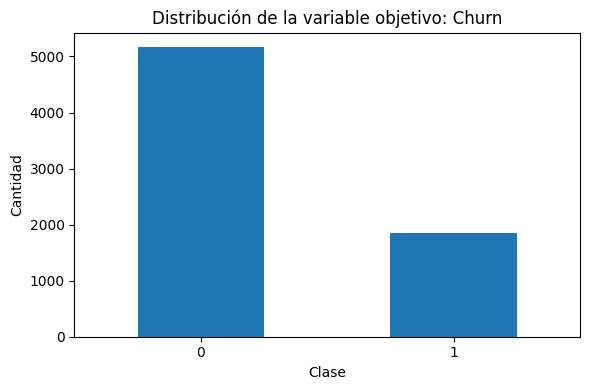


Dataset limpio guardado como: dataset_limpio.csv

AGENTE 1 COMPLETADO
Reporte del proceso:
{'filas_originales': 7043, 'columnas_originales': 21, 'nulos_directos': 0, 'duplicados_eliminados': 22, 'filas_limpias': 7021, 'columnas_limpias': 20, 'ruta_dataset_limpio': 'dataset_limpio.csv'}


In [13]:
agente1 = AgenteNormalizador(
    ruta_csv="TelcoCustomerChurn.csv",
    columna_objetivo="Churn"
)

df_limpio, reporte_normalizacion = agente1.ejecutar()